In [8]:
import torch
import torch.nn as nn
from torch.utils.data import dataloader
from torchvision.transforms import  transforms
import torchvision.utils as vutils
import numpy as np
from timeit import default_timer as timer
from tqdm.auto import tqdm 
import matplotlib.pyplot as plt
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda) 

2.10.0+cpu
False
None


In [9]:
import os
from PIL import Image
from torch.utils.data import Dataset

class CelebA(Dataset):
  def __init__(self, root, transform=None):
    self.root = root
    # Filter for common image extensions to ensure only image files are loaded
    self.image_files = [f for f in os.listdir(root) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    self.transform = transform

  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_path = os.path.join(self.root, self.image_files[idx])
    img = Image.open(img_path).convert('RGB')
    if self.transform:
      img = self.transform(img)
    return img

In [10]:
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [15]:
data_root = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba'

celebA_dataset = CelebA(root=data_root, transform=data_transform)

celebA_dataloader = torch.utils.data.DataLoader( celebA_dataset,
                                                batch_size=64,
                                                shuffle=True,
                                                num_workers=2,
                                                drop_last=True)

print(f'Length of the dataset:{len(celebA_dataset)}')
print(f'Length of the dataloader:{len(celebA_dataloader)}')

Length of the dataset:202599
Length of the dataloader:3165


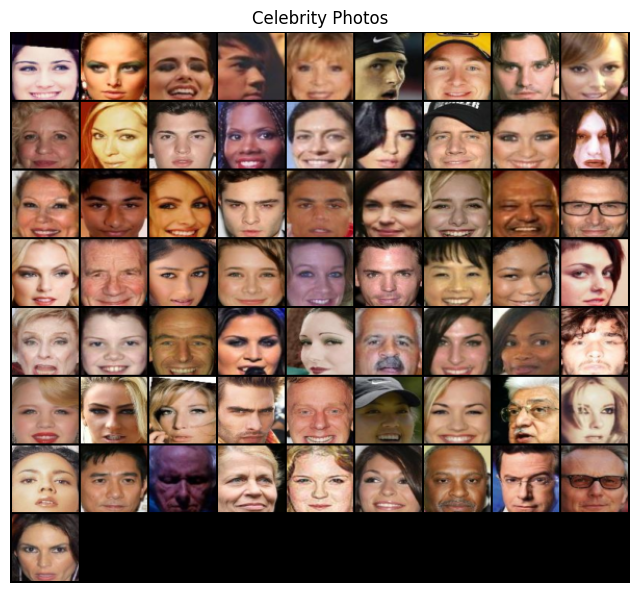

In [16]:
batch = next(iter(celebA_dataloader))
plt.figure(figsize=(8,8))
plt.axis('off')
plt.title('Celebrity Photos')
plt.imshow(np.transpose(vutils.make_grid(batch[:64], nrow=9, padding=2, normalize=True), (1,2,0)))
plt.show()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

In [ ]:
#variance schedule
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end , steps=T)
aplhas = 1. - betas 
alphas_cumprod = torch.cumprod(aplhas, dim=0)
alphas_cumprod = alphas_cumprod.to(device)

In [ ]:
#Forward pass 
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_lile(x0)
        
    sqrt_alphas_cumprod = torch.sqrt(aplhas_cumprod[t]).view(-1,-1,1,1)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod[t]).view(-1,-1,1,1)
    
    return sqrt_alphas_cumprod*x0 + sqrt_one_minus_alphas_cumprod*noise

In [ ]:
#SinusoidalPositionEmbeddings

import math 
import torch 

def Sinusoidal_Embeddings(torch.nn.Module):
    def __init__(self, dim:int):
        super().__init()
        assert dim % 2 ==0 , 'Embeddings must be divisble by two to create to sin and cos waves'
        self.dim = dim
    def forward(self, time_stamps:torch.Tensor) -> torch.Tensor:
        device = time_stamps.device
        half_dim = self.dim // 2
        scale  = math.log(10000)/(half_dim - 1)
        freq = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=divce) * -scale)
        embeddings = time_stamps[:, None].float() * freq[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings 

In [ ]:
#Time embeddings 

class Time_embeddings(torch.nn.Module):
    def __init__(self, time_emb_dim: int, out_dim: int):
        super().__init__()
        self.sinusoidal_emb = SinusoidalPositionEmbeddings(time_emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward(self, time_steps:torch.Tensor)-> torch.Tensor:
        raw_emb = self.sinusoidal_emb(time_steps)
        return self.mlp(raw_emb)